<a href="https://colab.research.google.com/github/duyhung-tran/B101-Group2-NLP-Project/blob/main/DetectorModel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Setup**

In [14]:
!pip install numpy torch datasets transformers sentencepiece protobuf accelerate evaluate tensorboard

Python(1567) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


In [15]:
import os
import pandas as pd
import numpy as np
import evaluate
from datasets import Dataset, load_dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments, IntervalStrategy, EarlyStoppingCallback
import torch
from sklearn.model_selection import train_test_split

# **Dataset**


In [16]:
train_df = pd.read_csv('informal_samples.csv', encoding="latin-1")
val_df = pd.read_csv('outsideval_informal_samples.csv', encoding="latin-1")

combined_df = pd.concat([train_df, val_df], ignore_index=True)

print(f"Shape of train_df: {train_df.shape}")
print(f"Shape of val_df: {val_df.shape}")
print(f"Shape of combined_df: {combined_df.shape}")
display(combined_df.head())

Shape of train_df: (5400, 3)
Shape of val_df: (1350, 3)
Shape of combined_df: (6750, 3)


,sample_text,sub-type,AI_label
0,it was the best of times it was the worst of t...,message,0
1,I will come with karnan car. Please wait till ...,message,0
2,yeah but dude i did that mistake some time ago...,message,0
3,in case of fire read this message i said in ca...,message,0
4,Yes just finished watching days of our lives. ...,message,0


In [17]:
raw_dataset = Dataset.from_pandas(combined_df)

# encode the AI_label column into type ClassLabel
raw_dataset = raw_dataset.class_encode_column("AI_label")

dataset = raw_dataset.train_test_split(test_size=0.2, seed=42, shuffle=True, stratify_by_column="AI_label")

# rename test set to val
dataset["val"] = dataset.pop("test")

dataset

Casting to class labels: 100%|███| 6750/6750 [00:00<00:00, 422138.34 examples/s]


DatasetDict({
    train: Dataset({
        features: ['sample_text', 'sub-type', 'AI_label'],
        num_rows: 5400
    })
    val: Dataset({
        features: ['sample_text', 'sub-type', 'AI_label'],
        num_rows: 1350
    })
})

# **Fine-Tuning Prep**

## **Tokenization**

In [18]:
# Load tokenizer needed by the base model

model = "microsoft/deberta-v3-small"
tokenizer = AutoTokenizer.from_pretrained(model, use_fast=True)

tokenizer

DebertaV2Tokenizer(name_or_path='microsoft/deberta-v3-small', vocab_size=128000, model_max_length=1000000000000000019884624838656, padding_side='right', truncation_side='right', special_tokens={'bos_token': '[CLS]', 'eos_token': '[SEP]', 'unk_token': '[UNK]', 'sep_token': '[SEP]', 'pad_token': '[PAD]', 'cls_token': '[CLS]', 'mask_token': '[MASK]'}, added_tokens_decoder={
	0: AddedToken("[PAD]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	1: AddedToken("[CLS]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	2: AddedToken("[SEP]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	3: AddedToken("[UNK]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	128000: AddedToken("[MASK]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
})

In [19]:
def tokenize(example):
  tokenized = tokenizer(example["sample_text"], truncation=True, padding="max_length", max_length=512) # 512 is the max, though the dataset should be safe enough from cleaning
  tokenized["labels"] = example["AI_label"]
  return tokenized

In [20]:
tokenized_dataset = dataset.map(tokenize, batched=True, remove_columns=["sample_text", "sub-type"])
tokenized_dataset

Map: 100%|█████████████████████████| 1350/1350 [00:00<00:00, 9956.27 examples/s]


DatasetDict({
    train: Dataset({
        features: ['AI_label', 'input_ids', 'token_type_ids', 'attention_mask', 'labels'],
        num_rows: 5400
    })
    val: Dataset({
        features: ['AI_label', 'input_ids', 'token_type_ids', 'attention_mask', 'labels'],
        num_rows: 1350
    })
})

## **Metrics Setup**

In [21]:
import numpy as np
import evaluate
from sklearn.metrics import precision_recall_fscore_support, roc_auc_score

accuracy_metric = evaluate.load("accuracy")

def compute_metrics(eval_pred):
    logits = eval_pred.predictions # Correctly access predictions attribute
    labels = eval_pred.label_ids  # Correctly access label_ids attribute
    preds = np.argmax(logits, axis=-1)

    # Accuracy
    accuracy = accuracy_metric.compute(predictions=preds, references=labels)["accuracy"]

    # Precision, Recall, F1 (macro + weighted)
    precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(
        labels, preds, average="macro", zero_division=0
    )
    _, _, f1_weighted, _ = precision_recall_fscore_support(
        labels, preds, average="weighted", zero_division=0
    )

    # ROC AUC
    try:
        auc = roc_auc_score(labels, logits[:,1])
    except ValueError:
        auc = float("nan")

    return {
        "accuracy": accuracy,
        "f1_macro": f1_macro,
        "f1_weighted": f1_weighted,
        "precision_macro": precision_macro,
        "recall_macro": recall_macro,
        "auc": auc,
    }

## **Training Config**

In [22]:
checkpoint = "microsoft/deberta-v3-small"
num_labels = 2
id2label = {0:"Human-Written", 1:"AI-Generated"}
label2id = {"Human-Written":0, "AI-Generated":1}
model = AutoModelForSequenceClassification.from_pretrained(checkpoint, num_labels=num_labels, id2label=id2label, label2id=label2id)

training_args = TrainingArguments(
    seed=42,
    output_dir="./results",
    num_train_epochs=5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    learning_rate=1e-5,
    warmup_ratio=0.1,
    max_grad_norm=1.0,
    fp16=False,                           # prevent overflow
    bf16=torch.cuda.is_bf16_supported(),
    logging_steps=10,
    metric_for_best_model="f1",
    load_best_model_at_end=True,
    eval_strategy="epoch",
    save_strategy="epoch"
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_dataset['train'],
    eval_dataset=tokenized_dataset['val'],
    compute_metrics=compute_metrics
)

Loading weights: 100%|█████████████████████| 102/102 [00:00<00:00, 34032.22it/s]
[transformers] DebertaV2ForSequenceClassification LOAD REPORT from: microsoft/deberta-v3-small
Key                                     | Status     | 
----------------------------------------+------------+-
lm_predictions.lm_head.dense.weight     | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED | 
mask_predictions.dense.bias             | UNEXPECTED | 
mask_predictions.classifier.bias        | UNEXPECTED | 
lm_predictions.lm_head.dense.bias       | UNEXPECTED | 
mask_predictions.classifier.weight      | UNEXPECTED | 
mask_predictions.dense.weight           | UNEXPECTED | 
lm_predictions.lm_head.bias             | UNEXPECTED | 
mask_predictions.LayerNorm.weight       | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED | 
mask_predictions.LayerNorm.bias         | UNEXPECTED | 
pooler.dense.weight                     | MISSING    | 
pooler.dense.bias                       

In [23]:
checkpoint = "microsoft/deberta-v3-small"
num_labels = 2
id2label = {0:"Human-Written", 1:"AI-Generated"}
label2id = {"Human-Written":0, "AI-Generated":1}
model = AutoModelForSequenceClassification.from_pretrained(checkpoint, num_labels=num_labels, id2label=id2label, label2id=label2id)

import torch
from transformers import TrainingArguments, EarlyStoppingCallback

training_args = TrainingArguments(
    seed=42,
    output_dir="./results_subtype_stratified",

    # 1. EPOCHS & BATCH SIZE
    num_train_epochs=3,                     # 3 epochs max (810 total steps)
    per_device_train_batch_size=16,         # Batch size 16 (or 8 with grad_accum=2)
    per_device_eval_batch_size=16,
    gradient_accumulation_steps=1,

    # 2. LEARNING RATE & SCHEDULER
    learning_rate=1.5e-5,                   # Conservative LR for transformer backbone
    lr_scheduler_type="cosine",             # Smooth decay prevents late-stage divergence
    warmup_steps=80,                        # ~10% of total training steps

    # 3. OPTIMIZER & STABILITY (Crucial for DeBERTa-v3 / RoBERTa)
    optim="adamw_torch_fused",              # Eliminates position embedding variance explosion
    adam_epsilon=1e-6,                      # Prevents numerical underflow / NaN gradients
    max_grad_norm=0.5,                      # Strict gradient clipping

    # 4. REGULARIZATION
    weight_decay=0.01,                      # L2 regularization
    label_smoothing_factor=0.05,            # Slight smoothing to prevent logit overconfidence

    # 5. PRECISION
    fp16=False,                             # Keep False for DeBERTa FP16 stability
    bf16=torch.cuda.is_bf16_supported(),    # Safe on Ampere GPUs (RTX 30xx/40xx, A100)

    # 6. EVALUATION & CHECKPOINTING
    eval_strategy="steps",
    eval_steps=45,                          # Evaluates ~6 times per epoch (every 45 steps)
    save_strategy="steps",
    save_steps=45,
    save_total_limit=2,
    logging_steps=15,

    # 7. MODEL SELECTION
    metric_for_best_model="f1",
    greater_is_better=True,
    load_best_model_at_end=True,
)

Loading weights: 100%|█████████████████████| 102/102 [00:00<00:00, 32628.05it/s]
[transformers] DebertaV2ForSequenceClassification LOAD REPORT from: microsoft/deberta-v3-small
Key                                     | Status     | 
----------------------------------------+------------+-
lm_predictions.lm_head.dense.weight     | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED | 
mask_predictions.dense.bias             | UNEXPECTED | 
mask_predictions.classifier.bias        | UNEXPECTED | 
lm_predictions.lm_head.dense.bias       | UNEXPECTED | 
mask_predictions.classifier.weight      | UNEXPECTED | 
mask_predictions.dense.weight           | UNEXPECTED | 
lm_predictions.lm_head.bias             | UNEXPECTED | 
mask_predictions.LayerNorm.weight       | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED | 
mask_predictions.LayerNorm.bias         | UNEXPECTED | 
pooler.dense.weight                     | MISSING    | 
pooler.dense.bias                       

# **Fine-Tuning an AI-Text Detector**

In [24]:
import torch
from transformers import (
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments,
    EarlyStoppingCallback
)
model = AutoModelForSequenceClassification.from_pretrained(
    "microsoft/deberta-v3-small",
    num_labels=2,
    id2label={0: "Human-Written", 1: "AI-Generated"},
    label2id={"Human-Written": 0, "AI-Generated": 1}
)

final_training_args = TrainingArguments(
    seed=42,
    output_dir="./deberta_v3_best",

    # Optuna Best Parameters
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    learning_rate=1.0317e-05,
    weight_decay=0.02586,
    warmup_steps=114,
    label_smoothing_factor=0.04114,

    lr_scheduler_type="cosine",
    optim="adamw_torch_fused" if torch.cuda.is_available() else "adamw_torch",
    adam_epsilon=1e-6,
    max_grad_norm=0.5,

    fp16=False,
    bf16=torch.cuda.is_bf16_supported(),

    eval_strategy="steps",
    eval_steps=45,
    save_strategy="steps",
    save_steps=45,
    save_total_limit=1,
    logging_steps=15,

    metric_for_best_model="accuracy",
    greater_is_better=True,
    load_best_model_at_end=True,
)

trainer = Trainer(
    model=model,
    args=final_training_args,
    train_dataset=tokenized_dataset["train"],
    eval_dataset=tokenized_dataset["val"],
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=4)]
)

# Run full final training run
trainer.train()

# Save final tuned model weights and tokenizer
trainer.save_model("./deberta_v3_final")
tokenizer.save_pretrained("./deberta_v3_final")

Loading weights: 100%|█████████████████████| 102/102 [00:00<00:00, 31641.08it/s]
[transformers] DebertaV2ForSequenceClassification LOAD REPORT from: microsoft/deberta-v3-small
Key                                     | Status     | 
----------------------------------------+------------+-
lm_predictions.lm_head.dense.weight     | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED | 
mask_predictions.dense.bias             | UNEXPECTED | 
mask_predictions.classifier.bias        | UNEXPECTED | 
lm_predictions.lm_head.dense.bias       | UNEXPECTED | 
mask_predictions.classifier.weight      | UNEXPECTED | 
mask_predictions.dense.weight           | UNEXPECTED | 
lm_predictions.lm_head.bias             | UNEXPECTED | 
mask_predictions.LayerNorm.weight       | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED | 
mask_predictions.LayerNorm.bias         | UNEXPECTED | 
pooler.dense.weight                     | MISSING    | 
pooler.dense.bias                       

RuntimeError: MPS backend out of memory (MPS allocated: 8.47 GiB, other allocations: 571.22 MiB, max allowed: 9.07 GiB). Tried to allocate 96.00 MiB on shared pool. Use PYTORCH_MPS_HIGH_WATERMARK_RATIO=0.0 to disable upper limit for memory allocations (may cause system failure).

## **Tensorboard**
For viewing train/eval metrics + graphs

**Local:**

Not sure on Google runtime, but locally, it times out in the notebook for me so I don't recommend running it here.

- In command line/terminal, go to your working directory
- **tensorboard --logdir=./logs --port=6006**
- Access localhost in browser


**Prelim**

mmmmmmmmm

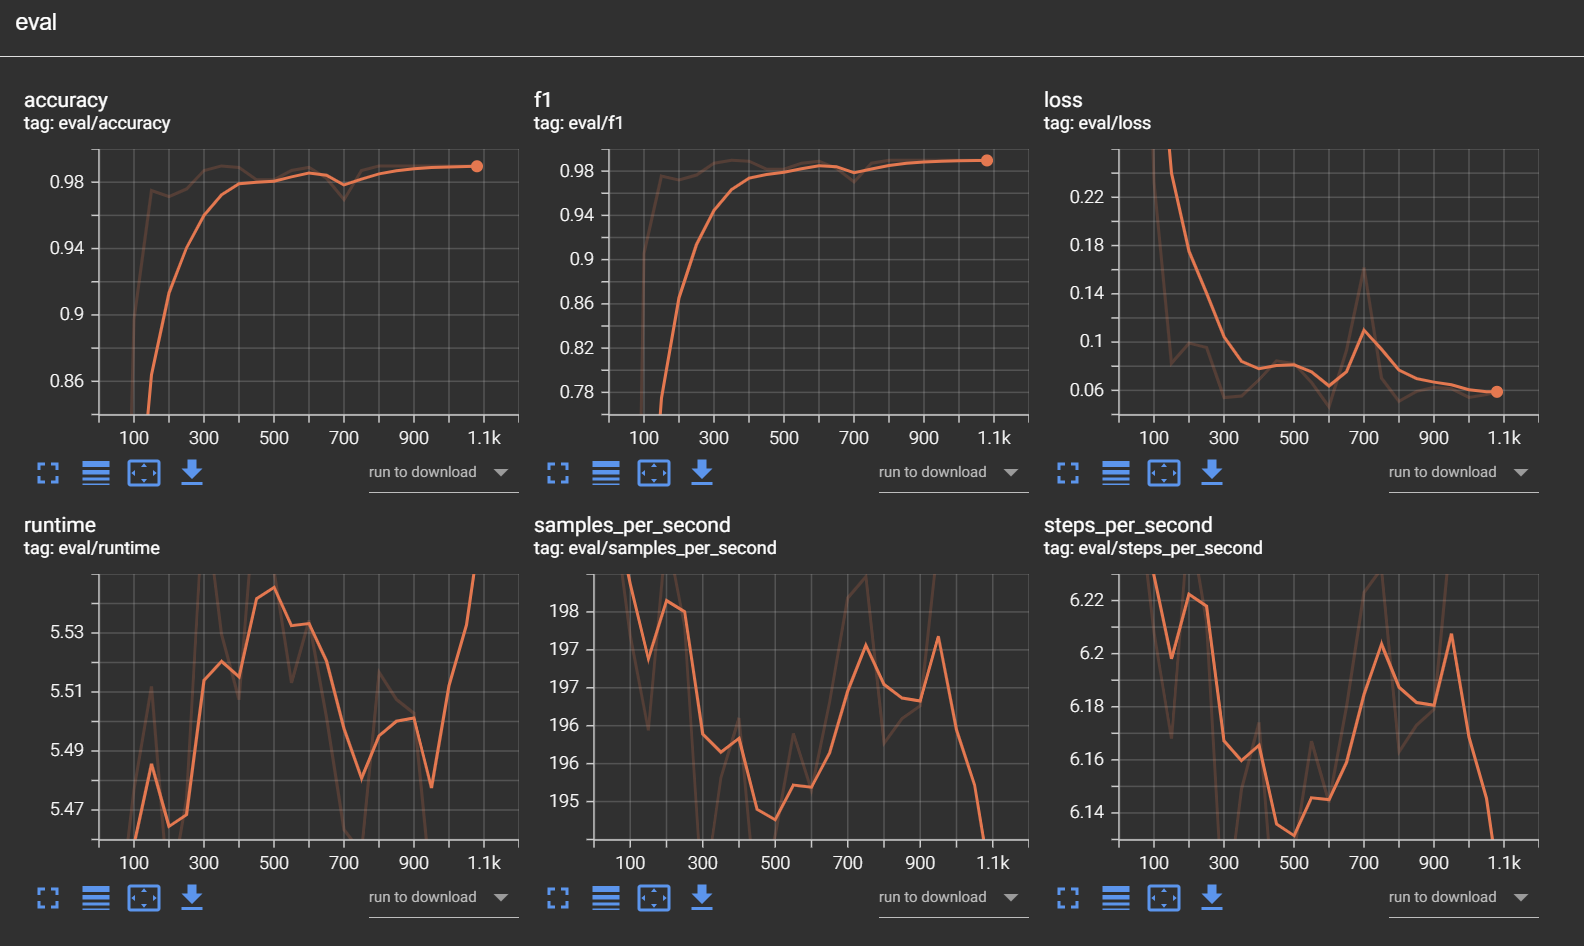

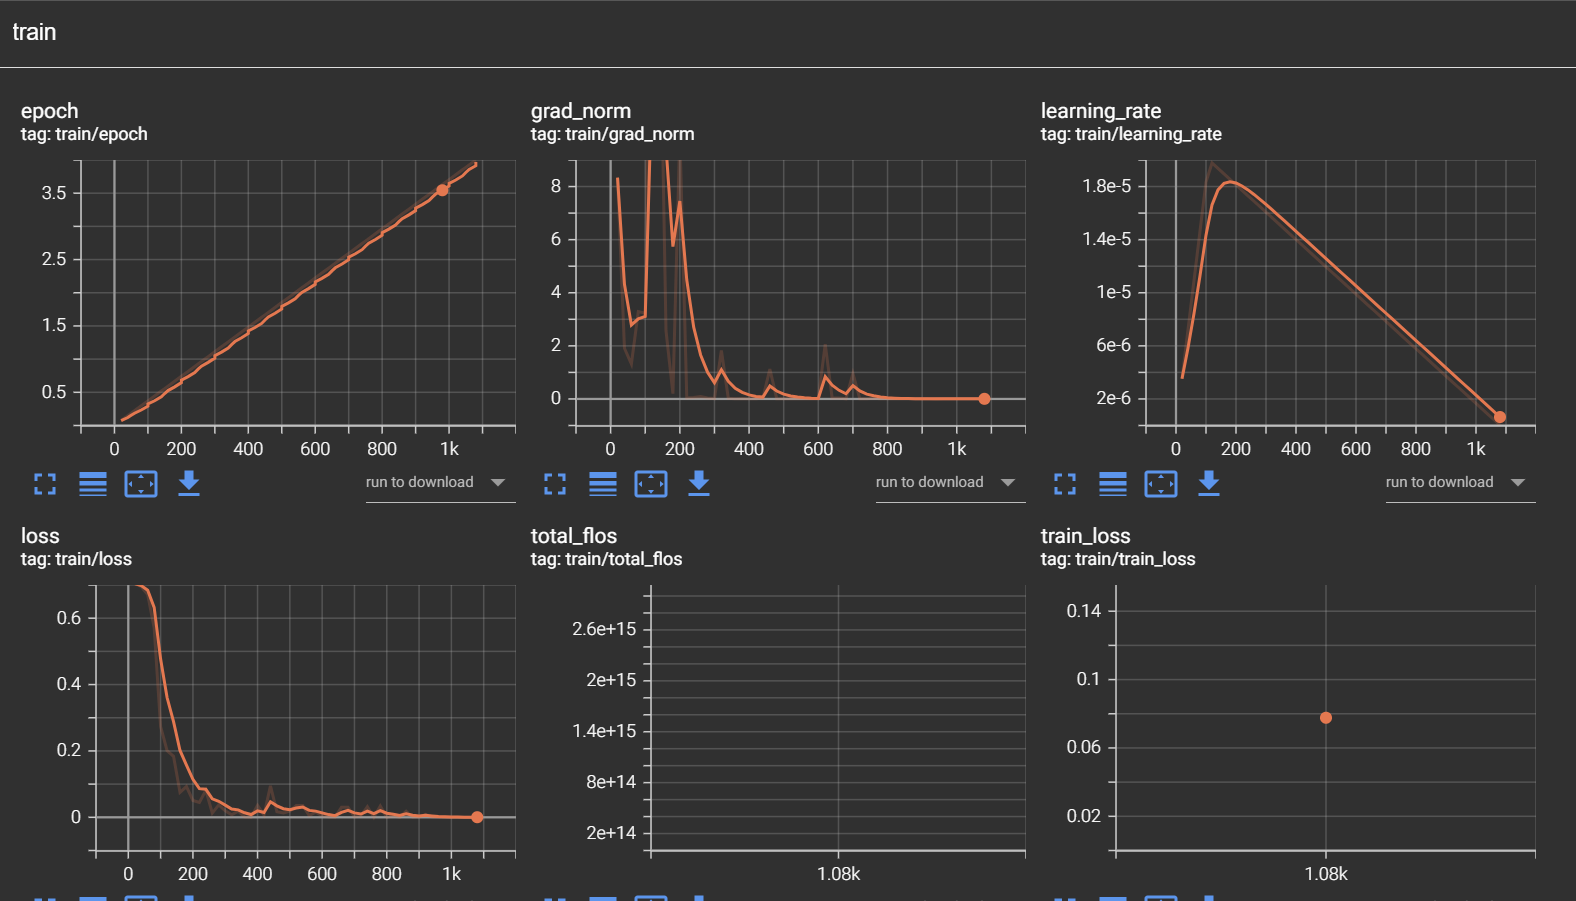

oh dear

LMAOOOOOOOOO

Prelim on Extended Val

In [ ]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.042505,0.063865,0.981481,0.981765
2,0.083615,0.020030,0.996296,0.996294
3,0.000127,0.037338,0.992593,0.992614
4,0.000101,0.036338,0.993333,0.993309


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=1352, training_loss=0.07378101201075991, metrics={'train_runtime': 699.311, 'train_samples_per_second': 30.888, 'train_steps_per_second': 1.933, 'total_flos': 2861397732556800.0, 'train_loss': 0.07378101201075991, 'epoch': 4.0})

***Val should be TEST, it's only learning any shortcuts between the training and val, which is bad bc these two are purposefully different

Val --> saved for Evaluation after fine-tuning